<a href="https://colab.research.google.com/github/KimMinWoooo/Hands-on-ML-repo/blob/main/11_training_deep_neural_networks_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chapter 11-1 – Training Deep Neural Networks**

Homework notebook

### 학번:  20192576

### 이름:  김민우

_This notebook contains all the sample code and solutions to the exercises in chapter 11._

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/ageron/handson-ml2/blob/master/11_training_deep_neural_networks.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20 and TensorFlow ≥2.0.

In [ ]:
# Python ≥3.5 is required
import sys
print("Python: ", sys.version_info)
assert sys.version_info >= (3, 7)

# Scikit-Learn ≥0.20 is required
import sklearn
print("sklearn version: ", sklearn.__version__)
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.8 is required
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# GPU test
print("GPU installed: ",tf.test.is_built_with_gpu_support())

# To prevent "CUDNN_STATUS_ALLOC_FAILED" error with GPUs
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Where to save the figures
from pathlib import Path

IMAGES_PATH = Path() / "images" / "11_deep"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

Python:  sys.version_info(major=3, minor=11, micro=11, releaselevel='final', serial=0)
sklearn version:  1.6.1
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
No GPU was detected. CNNs can be very slow without a GPU.
Go to Runtime > Change runtime and select a GPU hardware accelerator.
GPU installed:  True


# Vanishing/Exploding Gradients Problem

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

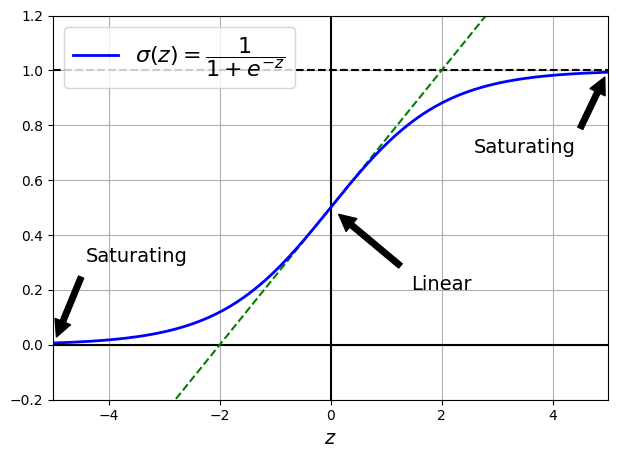

In [ ]:
z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

save_fig("sigmoid_saturation_plot")
plt.show()

## Xavier and He Initialization

In [ ]:
# Display all initializers in Keras
from tensorflow import keras
[name for name in dir(keras.initializers) if not name.startswith("_")]

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'HeNormal',
 'HeUniform',
 'Identity',
 'IdentityInitializer',
 'Initializer',
 'LecunNormal',
 'LecunUniform',
 'Ones',
 'Orthogonal',
 'OrthogonalInitializer',
 'RandomNormal',
 'RandomUniform',
 'STFT',
 'STFTInitializer',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'random_normal',
 'random_uniform',
 'serialize',
 'stft',
 'truncated_normal',
 'variance_scaling',
 'zeros']

In [ ]:
dense = tf.keras.layers.Dense(50, activation="relu",
                              kernel_initializer="he_normal")

In [ ]:
#Initializer capable of adapting its scale to the shape of weights tensors
he_avg_init = tf.keras.initializers.VarianceScaling(scale=2., mode="fan_avg",
                                                    distribution="uniform")
dense = tf.keras.layers.Dense(50, activation="sigmoid",
                              kernel_initializer=he_avg_init)

## Nonsaturating Activation Functions

### Leaky ReLU

In [ ]:
def leaky_relu(z, alpha=0.01):
    return np.maximum(alpha*z, z)

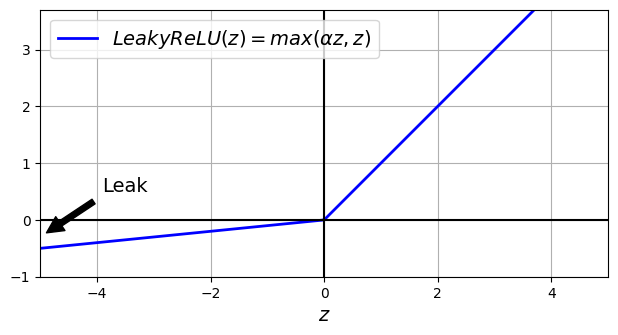

In [ ]:
z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

save_fig("leaky_relu_plot")
plt.show()

In [ ]:
# DIspaly all activation functions in Keras
[m for m in dir(keras.activations) if not m.startswith("_")]

['celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

In [ ]:
# Display all layers including "ReLU"
[m for m in dir(keras.layers) if "relu" in m.lower()]

['LeakyReLU', 'PReLU', 'ReLU', 'ThresholdedReLU']

Let's train a neural network on Fashion MNIST using the Leaky ReLU:

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.2),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(alpha=0.2),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [ ]:
#from tensorflow.keras.backend.tensorflow_backend import set_session

#gpus = tf.config.list_physical_devices('GPU')
#cpus = tf.config.list_physical_devices('CPU')
#tf.config.set_visible_devices(cpus)

In [ ]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5002 - loss: 1.6135 - val_accuracy: 0.6988 - val_loss: 0.8951
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7025 - loss: 0.8582 - val_accuracy: 0.7576 - val_loss: 0.7219
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7574 - loss: 0.7186 - val_accuracy: 0.7860 - val_loss: 0.6447
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7848 - loss: 0.6485 - val_accuracy: 0.8042 - val_loss: 0.5971
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8013 - loss: 0.6038 - val_accuracy: 0.8142 - val_loss: 0.5647
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8122 - loss: 0.5724 - val_accuracy: 0.8222 - val_loss: 0.5412
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8193 - loss: 0.5490 - val_accuracy: 0.8276 - val_loss: 0.5230
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8243 - loss: 0.53

Now let's try PReLU:

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

model1 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.PReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.PReLU(),
    keras.layers.Dense(10, activation="softmax")
])

In [ ]:
model1.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [ ]:
history = model1.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4224 - loss: 1.7862 - val_accuracy: 0.7106 - val_loss: 0.9453
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7163 - loss: 0.8957 - val_accuracy: 0.7678 - val_loss: 0.7450
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7641 - loss: 0.7373 - val_accuracy: 0.7866 - val_loss: 0.6597
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7884 - loss: 0.6597 - val_accuracy: 0.8030 - val_loss: 0.6067
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8034 - loss: 0.6104 - val_accuracy: 0.8120 - val_loss: 0.5719
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8127 - loss: 0.5764 - val_accuracy: 0.8190 - val_loss: 0.5464
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8205 - loss: 0.5511 - val_accuracy: 0.8230 - val_loss: 0.5268
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8257 - loss: 0.5314

### ELU

In [ ]:
def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

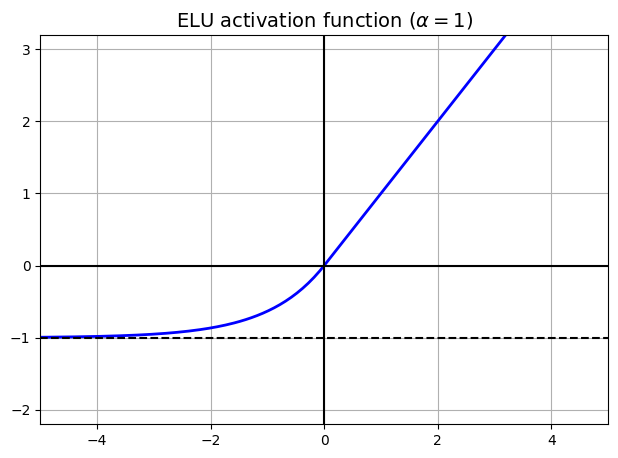

In [ ]:
plt.plot(z, elu(z), "b-", linewidth=2)
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k--')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.title(r"ELU activation function ($\alpha=1$)", fontsize=14)
plt.axis([-5, 5, -2.2, 3.2])

save_fig("elu_plot")
plt.show()

Implementing ELU in TensorFlow is trivial, just specify the activation function when building each layer:

In [ ]:
keras.layers.Dense(10, activation="elu", kernel_initializer="he_normal")

<Dense name=dense_8, built=False>

### SELU

This activation function was proposed in this [great paper](https://arxiv.org/pdf/1706.02515.pdf) by Günter Klambauer, Thomas Unterthiner and Andreas Mayr, published in June 2017. During training, a neural network composed exclusively of a stack of dense layers using the SELU activation function and LeCun initialization will self-normalize: the output of each layer will tend to preserve the same mean and variance during training, which solves the vanishing/exploding gradients problem. As a result, this activation function outperforms the other activation functions very significantly for such neural nets, so you should really try it out. Unfortunately, the self-normalizing property of the SELU activation function is easily broken: you cannot use ℓ<sub>1</sub> or ℓ<sub>2</sub> regularization, regular dropout, max-norm, skip connections or other non-sequential topologies (so recurrent neural networks won't self-normalize). However, in practice it works quite well with sequential CNNs. If you break self-normalization, SELU will not necessarily outperform other activation functions.

In [ ]:
from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
# (see equation 14 in the paper):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1/np.sqrt(2)) * np.exp(1/2) - 1)
scale_0_1 = (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e)) * np.sqrt(2 * np.pi) * (2 * erfc(np.sqrt(2))*np.e**2 + np.pi*erfc(1/np.sqrt(2))**2*np.e - 2*(2+np.pi)*erfc(1/np.sqrt(2))*np.sqrt(np.e)+np.pi+2)**(-1/2)

In [ ]:
def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

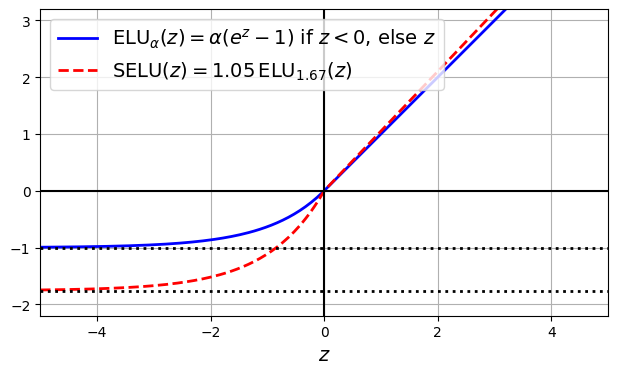

In [ ]:
z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

save_fig("elu_selu_plot")
plt.show()

By default, the SELU hyperparameters (`scale` and `alpha`) are tuned in such a way that the mean output of each neuron remains close to 0, and the standard deviation remains close to 1 (assuming the inputs are standardized with mean 0 and standard deviation 1 too, and other constraints are respected, as explained in the book). Using this activation function, even a 1,000 layer deep neural network preserves roughly mean 0 and standard deviation 1 across all layers, avoiding the exploding/vanishing gradients problem:

In [ ]:
np.random.seed(42)
Z = np.random.normal(size=(500, 100)) # standardized inputs
for layer in range(1000):
    W = np.random.normal(size=(100, 100), scale=np.sqrt(1 / 100)) # LeCun initialization
    Z = selu(np.dot(Z, W))
    means = np.mean(Z, axis=0).mean()
    stds = np.std(Z, axis=0).mean()
    if layer % 100 == 0:
        print("Layer {}: mean {:.2f}, std deviation {:.2f}".format(layer, means, stds))

Layer 0: mean -0.00, std deviation 1.00
Layer 100: mean 0.02, std deviation 0.96
Layer 200: mean 0.01, std deviation 0.90
Layer 300: mean -0.02, std deviation 0.92
Layer 400: mean 0.05, std deviation 0.89
Layer 500: mean 0.01, std deviation 0.93
Layer 600: mean 0.02, std deviation 0.92
Layer 700: mean -0.02, std deviation 0.90
Layer 800: mean 0.05, std deviation 0.83
Layer 900: mean 0.02, std deviation 1.00


Using SELU is easy:

In [ ]:
keras.layers.Dense(10, activation="selu",
                   kernel_initializer="lecun_normal")

<Dense name=dense_9, built=False>

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

model2 = keras.models.Sequential()
model2.add(keras.layers.Flatten(input_shape=[28, 28]))
model2.add(keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"))
model2.add(keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"))
model2.add(keras.layers.Dense(10, activation="softmax"))

In [ ]:
model2.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [ ]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [ ]:
history = model2.fit(X_train_scaled, y_train, epochs=10,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6708 - loss: 0.9654 - val_accuracy: 0.8172 - val_loss: 0.5212
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8194 - loss: 0.5193 - val_accuracy: 0.8318 - val_loss: 0.4672
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8380 - loss: 0.4696 - val_accuracy: 0.8388 - val_loss: 0.4420
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8460 - loss: 0.4427 - val_accuracy: 0.8478 - val_loss: 0.4262
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8529 - loss: 0.4244 - val_accuracy: 0.8504 - val_loss: 0.4151
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8580 - loss: 0.4105 - val_accuracy: 0.8518 - val_loss: 0.4065
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8615 - loss: 0.3993 - val_accuracy: 0.8544 - val_loss: 0.3997
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8649 - loss: 0.389

### Exercise 11.1  
Build the same model as above with elu activation function, train the model, and compare the results. (The same training procedure as above)

In [32]:
# Ex.11.1a Model with elu activation
tf.random.set_seed(42)
np.random.seed(42)

model3 = tf.keras.Sequential()
model3.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model3.add(tf.keras.layers.Dense(100, activation="elu",
                                    kernel_initializer="he_normal")) # He 초기화 사용
model3.add(tf.keras.layers.Dense(10, activation="softmax"))

model3.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), # SGD 최적화기 사용
              metrics=["accuracy"])

history3 = model3.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.2925 - loss: 2.0182 - val_accuracy: 0.6424 - val_loss: 0.9983
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.5236 - loss: 1.2347 - val_accuracy: 0.5816 - val_loss: 1.0341
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.5859 - loss: 1.0411 - val_accuracy: 0.5662 - val_loss: 1.0204
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.6403 - loss: 0.9040 - val_accuracy: 0.6952 - val_loss: 0.8010
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.6916 - loss: 0.7835 - val_accuracy: 0.7236 - val_loss: 0.7339


#### Ex.11.1b Compare the results of loss, val_accuracy and training time for LeakyReLU, PReLU, SELU, and ELU  


활성화 함수	| 최종 Validation Loss	| 최종 Validation Accuracy	| 훈련 시간 (총합)

LeakyReLU	  |   0.4862 |	0.8364 |	약 84초

PReLU	| 0.4874 |	0.8338	| 약 74초

SELU |	0.3850 |	0.8584 |	약 72초

ELU	| 0.7339	| 0.7236	| 약 167초

가장 좋은 검증 정확도 (0.8584)를 달성한 함수 : SELU


#### SELU activation in the very deep network  
Let's create a neural net for Fashion MNIST with 100 hidden layers, using the SELU activation function:

In [33]:
np.random.seed(42)
tf.random.set_seed(42)

In [34]:
model4 = keras.models.Sequential()
model4.add(keras.layers.Flatten(input_shape=[28, 28]))
model4.add(keras.layers.Dense(300, activation="selu",
                             kernel_initializer="lecun_normal"))
for layer in range(99):
    model4.add(keras.layers.Dense(100, activation="selu",
                                 kernel_initializer="lecun_normal"))
model4.add(keras.layers.Dense(10, activation="softmax"))

In [35]:
model4.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

Now let's train it. Do not forget to scale the inputs to mean 0 and standard deviation 1:

In [36]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [37]:
history = model4.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.4261 - loss: 1.4938 - val_accuracy: 0.6934 - val_loss: 0.8409
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.6882 - loss: 0.8391 - val_accuracy: 0.7260 - val_loss: 0.7811
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.6941 - loss: 0.8061 - val_accuracy: 0.7424 - val_loss: 0.6840
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.7626 - loss: 0.6409 - val_accuracy: 0.7794 - val_loss: 0.5968
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.7880 - loss: 0.5832 - val_accuracy: 0.7948 - val_loss: 0.5588


Now look at what happens if we try to use the ReLU activation function instead:

In [38]:
np.random.seed(42)
tf.random.set_seed(42)

In [39]:
model5 = keras.models.Sequential()
model5.add(keras.layers.Flatten(input_shape=[28, 28]))
model5.add(keras.layers.Dense(300, activation="relu", kernel_initializer="he_normal"))
for layer in range(99):
    model5.add(keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"))
model5.add(keras.layers.Dense(10, activation="softmax"))

In [40]:
model5.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [41]:
history = model5.fit(X_train_scaled, y_train, epochs=5,
                    validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.1816 - loss: 2.0897 - val_accuracy: 0.2228 - val_loss: 2.0080
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.3356 - loss: 1.6971 - val_accuracy: 0.3634 - val_loss: 1.4908
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.4398 - loss: 1.3262 - val_accuracy: 0.6244 - val_loss: 1.0303
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.6160 - loss: 0.9968 - val_accuracy: 0.6496 - val_loss: 0.9177
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.6802 - loss: 0.8141 - val_accuracy: 0.6866 - val_loss: 0.8234


Not great at all, we suffered from the vanishing/exploding gradients problem.

### GELU, Swish and Mish

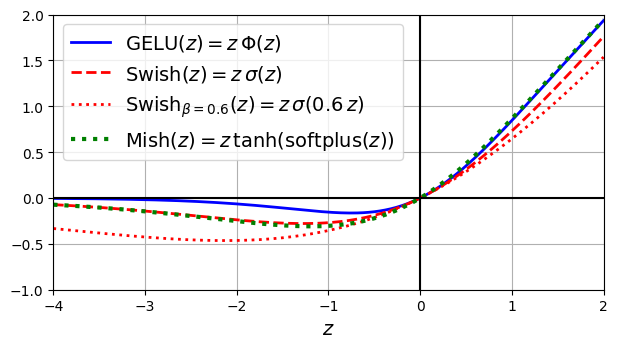

In [42]:
# extra code – this cell generates and saves Figure 11–4

def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

z = np.linspace(-4, 2, 200)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

save_fig("gelu_swish_mish_plot")
plt.show()

# Batch Normalization

In [43]:
# extra code - clear the name counters and set the random seed
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [44]:
model6= keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

In [45]:
model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 300)                 │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [46]:
bn1 = model6.layers[1]
[(var.name, var.trainable) for var in bn1.variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

In [47]:
model6.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",
              metrics=["accuracy"])

In [48]:
history = model6.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7660 - loss: 0.6964 - val_accuracy: 0.8584 - val_loss: 0.3894
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8620 - loss: 0.3908 - val_accuracy: 0.8696 - val_loss: 0.3607


In [49]:
# bn1 after training
bn1 = model6.layers[1]
[(var.name, var.trainable) for var in bn1.variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

Sometimes applying BN before the activation function works better (there's a debate on this topic). Moreover, the layer before a `BatchNormalization` layer does not need to have bias terms, since the `BatchNormalization` layer some as well, it would be a waste of parameters, so you can set `use_bias=False` when creating those layers:

In [50]:
model7 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])


In [51]:
model7.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["accuracy"])

In [52]:
history = model7.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5233 - loss: 1.4465 - val_accuracy: 0.7742 - val_loss: 0.7126
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7646 - loss: 0.7327 - val_accuracy: 0.8024 - val_loss: 0.5874


## Gradient Clipping

All `tf.keras.optimizers` accept `clipnorm` or `clipvalue` arguments:

In [53]:
optimizer = keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

In [54]:
optimizer = keras.optimizers.SGD(clipnorm=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

## Reusing Pretrained Layers

### Reusing a Keras model

Let's split the fashion MNIST training set in two:
* `X_train_A`: all images of all items except for sandals and shirts (classes 5 and 6).
* `X_train_B`: a much smaller training set of just the first 200 images of sandals or shirts.

The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (sneakers, ankle boots, coats, t-shirts, etc.) are somewhat similar to classes in set B (sandals and shirts). However, since we are using `Dense` layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image, as we will see in the CNN chapter).

In [55]:
# extra code – split Fashion MNIST into tasks A and B, then train and save
#              model A to "my_model_A".

pos_class_id = class_names.index("Pullover")
neg_class_id = class_names.index("T-shirt/top")

def split_dataset(X, y):
    y_for_B = (y == pos_class_id) | (y == neg_class_id) # Pullover or T-shirt/top
    y_A = y[~y_for_B]
#    y_A[y_A > 6] -= 2
    y_B = (y[y_for_B] == pos_class_id).astype(np.float32) # binary classification task: is it a shirt (class 6)?
    old_class_ids = list(set(range(10)) - set([neg_class_id, pos_class_id])) # class indices 7, 8, 9 should be moved to 5, 6, 7
    for old_class_id, new_class_id in zip(old_class_ids, range(8)):
        y_A[y_A == old_class_id] = new_class_id  # reorder class ids for A
    return ((X[~y_for_B], y_A), (X[y_for_B], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

In [56]:
X_train_A.shape

(44011, 28, 28)

In [57]:
X_train_B.shape

(200, 28, 28)

In [58]:
y_train_A[:30]

array([7, 1, 5, 3, 3, 7, 3, 3, 5, 7, 0, 4, 2, 1, 0, 2, 6, 2, 1, 2, 2, 3,
       1, 4, 4, 6, 3, 0, 4, 4], dtype=uint8)

In [59]:
y_train_B[:30]

array([0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0.,
       1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1.], dtype=float32)

In [60]:
tf.random.set_seed(42)
np.random.seed(42)

In [61]:
model_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(8, activation="softmax")
])

model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))
model_A.save("my_model_A.keras")

Epoch 1/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5232 - loss: 1.5045 - val_accuracy: 0.7867 - val_loss: 0.6932
Epoch 2/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7982 - loss: 0.6388 - val_accuracy: 0.8325 - val_loss: 0.5102
Epoch 3/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8422 - loss: 0.4933 - val_accuracy: 0.8549 - val_loss: 0.4355
Epoch 4/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8628 - loss: 0.4253 - val_accuracy: 0.8681 - val_loss: 0.3930
Epoch 5/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8746 - loss: 0.3843 - val_accuracy: 0.8747 - val_loss: 0.3661
Epoch 6/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8811 - loss: 0.3569 - val_accuracy: 0.8799 - val_loss: 0.3475
Epoch 7/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8865 - loss: 0.3372 - val_accuracy: 0.8839 - val_loss: 0.3337
Epoch 8/20
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8907 - loss: 0.3224 - 

In [74]:
# extra code – train and evaluate model B, without reusing model A

tf.random.set_seed(42)
model_B = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_B.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])
history = model_B.fit(X_train_B, y_train_B, epochs=20,
                      validation_data=(X_valid_B, y_valid_B))
model_B.evaluate(X_test_B, y_test_B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5699 - loss: 0.8954 - val_accuracy: 0.5153 - val_loss: 0.7931
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5699 - loss: 0.7450 - val_accuracy: 0.5153 - val_loss: 0.6896
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5699 - loss: 0.6553 - val_accuracy: 0.5282 - val_loss: 0.6270
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5812 - loss: 0.5996 - val_accuracy: 0.5994 - val_loss: 0.5855
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6549 - loss: 0.5627 - val_accuracy: 0.6963 - val_loss: 0.5562
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7214 - loss: 0.5365 - val_accuracy: 0.7774 - val_loss: 0.5340
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7788 - loss: 0.5162 - val_accuracy: 0.8121 - val_loss: 0.5158
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8195 - loss: 0.4990 - val_accuracy: 0.8427 - val_loss: 0.5003


[0.40284228324890137, 0.9144999980926514]

Model B reaches 91.85% accuracy on the test set. Now let's try reusing the pretrained model A.

In [63]:
model_A = tf.keras.models.load_model("my_model_A.keras")
model_B_on_A = tf.keras.Sequential(model_A.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [64]:
model_A.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 8)                   │             808 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 99,510 (388.71 KB)

 Trainable params: 99,508 (388.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Note that `model_B_on_A` and `model_A` actually share layers now, so when we train one, it will update both models. If we want to avoid that, we need to build `model_B_on_A` on top of a *clone* of `model_A`:

In [79]:
tf.random.set_seed(42)  # extra code – ensure reproducibility
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [80]:
# extra code – creating model_B_on_A just like in the previous cell
model_B_on_A = tf.keras.Sequential(model_A_clone.layers[:-1])
model_B_on_A.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [81]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])

In [88]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))

for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B_on_A.compile(loss="binary_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))

Epoch 1/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9599 - loss: 0.1857 - val_accuracy: 0.9466 - val_loss: 0.2234
Epoch 2/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9599 - loss: 0.1830 - val_accuracy: 0.9466 - val_loss: 0.2212
Epoch 3/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9599 - loss: 0.1805 - val_accuracy: 0.9476 - val_loss: 0.2190
Epoch 4/4
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9599 - loss: 0.1780 - val_accuracy: 0.9476 - val_loss: 0.2170
Epoch 1/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9599 - loss: 0.1756 - val_accuracy: 0.9496 - val_loss: 0.2150
Epoch 2/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9599 - loss: 0.1733 - val_accuracy: 0.9486 - val_loss: 0.2131
Epoch 3/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9599 - loss: 0.1711 - val_accuracy: 0.9486 - val_loss: 0.2113
Epoch 4/16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9599 - loss: 0.1690 - val_accuracy: 0.9486 - val_loss: 0.2096
Epoc

So, what's the final verdict?

In [76]:
model_B.evaluate(X_test_B, y_test_B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9195 - loss: 0.4031


[0.40284228324890137, 0.9144999980926514]

In [89]:
model_B_on_A.evaluate(X_test_B, y_test_B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9388 - loss: 0.2031


[0.2116602212190628, 0.9355000257492065]

### ==P1. Calculate the change of the error rate==

In [90]:
#1-(100 - accuracy of model_B_on_A) / (100 - accuracy of model_B)
1 - (100 - 93.55) / (100 - 91.45)

0.24561403508771873

#### Answer: the model's accuracy went up 2 percentage points, from 91.85% to 93.85%. This means the error rate dropped by almost 25%:

### Exercise 11.2  
"Reusing a Keras model" 부분에서 Fashion MNIST의 class 5,6,7을 제외하고 7개의 class로 학습하고 class 5,6,7에 대해 300개의 학습데이터를 이용하여 단독 학습한 결과와 transfer leranng을 이용한 경우에 대해 비교하시오. 제외시키는 class가 3개로 늘어난 것 외에는 모두 위의 실습 코드와 동일하게 작성하시오. 결과를 비교하고 분석하시오.

In [96]:
# Ex.1.2a 7개 class 데이터를 이용한 학습
def split_dataset(X, y):
    y_5_to_7 = (y == 5) | (y == 6) | (y == 7)
    X_A = X[~y_5_to_7]
    y_A = y[~y_5_to_7]
    y_A[y_A > 4] -= 3  # class indices 8, 9 should be moved to 5, 6
    X_C = X[y_5_to_7]
    y_C = y[y_5_to_7]  # Ternary classification task:
    y_C -= 5
    y_C = y_C.astype(np.float32)
    return ((X_A, y_A),
            (X_C, y_C))

(X_train_A, y_train_A), (X_train_C, y_train_C) = split_dataset(X_train_scaled, y_train)
(X_valid_A, y_valid_A), (X_valid_C, y_valid_C) = split_dataset(X_valid_scaled, y_valid)
(X_test_A, y_test_A), (X_test_C, y_test_C) = split_dataset(X_test_scaled, y_test)

# X_train_C, y_train_C의 크기를 300개로 제한
X_train_C = X_train_C[:300]
y_train_C = y_train_C[:300]

In [97]:
X_train_A.shape
X_train_C.shape

(300, 28, 28)

In [98]:
y_train_C[:30]

array([2., 0., 0., 0., 0., 2., 1., 0., 1., 1., 0., 1., 1., 2., 0., 2., 2.,
       1., 1., 0., 0., 0., 1., 1., 0., 2., 2., 2., 1., 1.], dtype=float32)

In [99]:
y_valid_C[:30]

array([1., 0., 2., 1., 2., 2., 0., 1., 2., 2., 1., 2., 1., 0., 0., 2., 2.,
       0., 0., 1., 1., 2., 0., 1., 2., 2., 2., 1., 0., 0.], dtype=float32)

In [102]:
tf.random.set_seed(42)
np.random.seed(42)

model1_A = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(7, activation="softmax") # 7개 노드로 변경
])

model1_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])

In [103]:
history = model1_A.fit(X_train_A, y_train_A, epochs=20,
                      validation_data=(X_valid_A, y_valid_A))
model1_A.save("my_model_1A.keras")

Epoch 1/20
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6211 - loss: 1.1399 - val_accuracy: 0.8545 - val_loss: 0.4295
Epoch 2/20
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8662 - loss: 0.4083 - val_accuracy: 0.8754 - val_loss: 0.3468
Epoch 3/20
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8852 - loss: 0.3399 - val_accuracy: 0.8827 - val_loss: 0.3118
Epoch 4/20
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8942 - loss: 0.3082 - val_accuracy: 0.8927 - val_loss: 0.2920
Epoch 5/20
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9011 - loss: 0.2891 - val_accuracy: 0.8966 - val_loss: 0.2785
Epoch 6/20
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9054 - loss: 0.2756 - val_accuracy: 0.9014 - val_loss: 0.2685
Epoch 7/20
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9090 - loss: 0.2651 - val_accuracy: 0.9056 - val_loss: 0.2606
Epoch 8/20
1201/1201 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9122 - loss: 0.2568 - 

In [104]:
# Ex.11.2b 300개 데이터를 이용한 3개 class에 대한 학습
model_C = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(3, activation="softmax")  # 3개 클래스
])

model_C.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
                metrics=["accuracy"])

In [105]:
history = model_C.fit(X_train_C, y_train_C, epochs=20,
                      validation_data=(X_valid_C, y_valid_C))

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3308 - loss: 2.7546 - val_accuracy: 0.3324 - val_loss: 1.9004
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3406 - loss: 1.7217 - val_accuracy: 0.3585 - val_loss: 1.4121
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3715 - loss: 1.3109 - val_accuracy: 0.4254 - val_loss: 1.1729
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4616 - loss: 1.0969 - val_accuracy: 0.5000 - val_loss: 1.0285
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5550 - loss: 0.9602 - val_accuracy: 0.5690 - val_loss: 0.9282
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6146 - loss: 0.8607 - val_accuracy: 0.6303 - val_loss: 0.8538
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6867 - loss: 0.7835 - val_accuracy: 0.6754 - val_loss: 0.7947
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7634 - loss: 0.7212 - val_accuracy: 0.7099 - v

In [106]:
model_C.evaluate(X_test_C, y_test_C)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8302 - loss: 0.4934


[0.4938945174217224, 0.828000009059906]

In [107]:
#Ex. 11.2c Transfer learning using pretrained layers
model_A = tf.keras.models.load_model("my_model_1A.keras")
model_C_on_A = tf.keras.Sequential(model_A.layers[:-1])
# replace output layer: 8 nodes -> 3 node
model_C_on_A.add(tf.keras.layers.Dense(3, activation="softmax"))

In [108]:
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [109]:
for layer in model_C_on_A.layers[:-1]:
    layer.trainable = False # 재사용할 레이어 동결

optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_C_on_A.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                     metrics=["accuracy"])

In [110]:
history = model_C_on_A.fit(X_train_C, y_train_C, epochs=4,
                           validation_data=(X_valid_C, y_valid_C))

for layer in model_C_on_A.layers[:-1]:
    layer.trainable = True # 동결 해제

history = model_C_on_A.fit(X_train_C, y_train_C, epochs=16,
                           validation_data=(X_valid_C, y_valid_C))

Epoch 1/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3565 - loss: 1.6333 - val_accuracy: 0.3324 - val_loss: 1.5563
Epoch 2/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3458 - loss: 1.4513 - val_accuracy: 0.3620 - val_loss: 1.3850
Epoch 3/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3641 - loss: 1.3060 - val_accuracy: 0.3817 - val_loss: 1.2524
Epoch 4/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4034 - loss: 1.1933 - val_accuracy: 0.3944 - val_loss: 1.1521
Epoch 1/16
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4299 - loss: 1.1078 - val_accuracy: 0.4232 - val_loss: 1.0770
Epoch 2/16
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4739 - loss: 1.0427 - val_accuracy: 0.4493 - val_loss: 1.0198
Epoch 3/16
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5183 - loss: 0.9920 - val_accuracy: 0.4852 - val_loss: 0.9750
Epoch 4/16
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5465 - loss: 0.9513 - val_accuracy: 0.5183 - val_l

In [111]:
test_loss, test_acc = model_C_on_A.evaluate(X_test_C, y_test_C, verbose=0)
print(f"전이 학습 모델의 테스트 정확도: {test_acc}")

전이 학습 모델의 테스트 정확도: 0.6526666879653931


In [112]:
# 독립적으로 훈련된 모델 C의 성능
loss_C, accuracy_C = model_C.evaluate(X_test_C, y_test_C, verbose=0)
print(f"독립적으로 훈련된 모델 C의 테스트 정확도: {accuracy_C}")

독립적으로 훈련된 모델 C의 테스트 정확도: 0.828000009059906


#### Ex.11.2d 결과비교

In [114]:
print("\n모델 1A의 훈련 기록:")
print(history.history)

print("\n모델 C의 훈련 기록 (독립적):")
print(history.history)

print("\n모델 C on A의 훈련 기록 (전이 학습):")
print(history.history)

print("\n독립적으로 훈련된 모델 C의 성능:")
print(f"손실: {loss_C}")
print(f"정확도: {accuracy_C}")

print("\n전이 학습 사용 후 모델 C on A의 성능:")
print(f"손실: {test_loss}")
print(f"정확도: {test_acc}")


모델 1A의 훈련 기록:
{'accuracy': [0.41333332657814026, 0.4533333480358124, 0.4933333396911621, 0.5266666412353516, 0.5400000214576721, 0.5600000023841858, 0.5766666531562805, 0.5899999737739563, 0.6066666841506958, 0.6166666746139526, 0.6299999952316284, 0.6399999856948853, 0.6433333158493042, 0.6466666460037231, 0.653333306312561, 0.6566666960716248], 'loss': [1.1163042783737183, 1.055951476097107, 1.0088365077972412, 0.9707121849060059, 0.9387884736061096, 0.9112970232963562, 0.8871107697486877, 0.8654890656471252, 0.8459237813949585, 0.8280513882637024, 0.8116013407707214, 0.7963652610778809, 0.782178521156311, 0.7689082622528076, 0.756445586681366, 0.7446997165679932], 'val_accuracy': [0.42323943972587585, 0.4492957890033722, 0.48521125316619873, 0.5183098316192627, 0.5380281805992126, 0.5556337833404541, 0.5746479034423828, 0.5880281925201416, 0.6000000238418579, 0.608450710773468, 0.6147887110710144, 0.6204225420951843, 0.6239436864852905, 0.6330986022949219, 0.6408450603485107, 0.647